
# ERA5 Data Visualization and Analysis

This notebook provides comprehensive visualization and exploratory analysis of the preprocessed ERA5 climate data. The analysis includes data quality assessment, spatial coverage mapping, temporal patterns, and interactive animations.

## Visualization Components

1. **Data Quality Assessment**: Missing value analysis and dataset statistics
2. **Dataset Overview**: Dimensions, variables, and metadata inspection
3. **Spatial Visualization**: Geographic distribution of observation points
4. **Temporal Analysis**: Time series evolution at specific locations
5. **Spatiotemporal Animation**: Dynamic visualization of variable evolution across space and time

In [1]:
%matplotlib inline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Data processing libraries
import xarray as xr
import numpy as np
import pandas as pd
import glob
import os
import time

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Jupyter utilities
from IPython.display import display, clear_output

## 1. Dataset Variables Reference

The ERA5 dataset comprises **14 physical variables**: 11 meteorological parameters and 3 wave characteristics.

### 1.1 Coordinate Variables

- **`valid_time`**: Temporal coordinate (hourly timestamps)
- **`latitude`**: Latitude coordinates (degrees North)
- **`longitude`**: Longitude coordinates (degrees East/West)

### 1.2 Meteorological Variables (11)

| Variable | Description | Units |
|----------|-------------|-------|
| `u10` | 10m U-component of wind | m/s |
| `v10` | 10m V-component of wind | m/s |
| `d2m` | 2m dewpoint temperature | K |
| `t2m` | 2m temperature | K |
| `msl` | Mean sea level pressure | Pa |
| `sst` | Sea surface temperature | K |
| `skt` | Skin temperature | K |
| `sp` | Surface pressure | Pa |
| `ssrd` | Surface solar radiation downwards | J/m² |
| `strd` | Surface thermal radiation downwards | J/m² |
| `tp` | Total precipitation | m |

### 1.3 Wave Variables (3) - Target Parameters

| Variable | Description | Units |
|----------|-------------|-------|
| `mwd` | Mean wave direction | degrees |
| `mwp` | Mean wave period | seconds |
| `swh` | Significant wave height | meters |
| `mwd_sin` | Mean wave direction Sin | [-1 ; 1] |
| `mwd_cos` | Mean wave direction Cos | [-1 ; 1] |

**Note**: Wave variables serve as both input features and prediction targets in the machine learning models.

In [3]:
## Dataset Overview

# Load both datasets
folder_train = "dataset_train"
folder_test = "dataset_test"

ds_train = xr.open_dataset(f"{folder_train}/combined2.nc")
ds_test = xr.open_dataset(f"{folder_test}/combined2.nc")

# Display dataset statistics
print("Dataset Dimensions")
print("=" * 50)
print(f"Training points: {ds_train.dims['point']}")
print(f"Testing points: {ds_test.dims['point']}")
print(f"Time steps: {ds_train.dims['valid_time']}")

print("\nTemporal Coverage")
print("=" * 50)
print(f"Start date: {pd.Timestamp(ds_train.valid_time.values[0])}")
print(f"End date: {pd.Timestamp(ds_train.valid_time.values[-1])}")
print(f"Duration: {len(ds_train.valid_time)} hours")

# Close datasets
ds_train.close()
ds_test.close()

Dataset Dimensions
Training points: 105
Testing points: 25
Time steps: 6624

Temporal Coverage
Start date: 2025-01-01 00:00:00
End date: 2025-10-03 23:00:00
Duration: 6624 hours


## 5. Dataset Structure Information

Examine dataset dimensions, available variables, and metadata attributes.

In [48]:
# Load dataset for inspection
folder = "dataset_train"
ds = xr.open_dataset(f"{folder}/combined2.nc")

print("Dataset Dimensions:")
print("-" * 50)
print(ds.dims)

print("\nData Variables:")
print("-" * 50)
print(ds.data_vars)

print("\nGlobal Attributes:")
print("-" * 50)
print(ds.attrs if ds.attrs else "No global attributes")

# Close dataset
ds.close()

Dataset Dimensions:
--------------------------------------------------
FrozenMappingWarningOnValuesAccess({'point': 105, 'valid_time': 6624})

Data Variables:
--------------------------------------------------
Data variables:
    u10      (point, valid_time) float32 3MB ...
    v10      (point, valid_time) float32 3MB ...
    d2m      (point, valid_time) float32 3MB ...
    t2m      (point, valid_time) float32 3MB ...
    msl      (point, valid_time) float32 3MB ...
    sst      (point, valid_time) float32 3MB ...
    skt      (point, valid_time) float32 3MB ...
    sp       (point, valid_time) float32 3MB ...
    ssrd     (point, valid_time) float32 3MB ...
    strd     (point, valid_time) float32 3MB ...
    tp       (point, valid_time) float32 3MB ...
    mwd      (point, valid_time) float32 3MB ...
    mwp      (point, valid_time) float32 3MB ...
    swh      (point, valid_time) float32 3MB ...
    mwd_sin  (point, valid_time) float32 3MB ...
    mwd_cos  (point, valid_time) float3

## 6. Spatial Coverage Visualization

Geographic distribution of training and testing observation points across the Azores region, displaying the spatial sampling strategy used for model development.

c:\Users\berna\anaconda3\envs\dataz\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


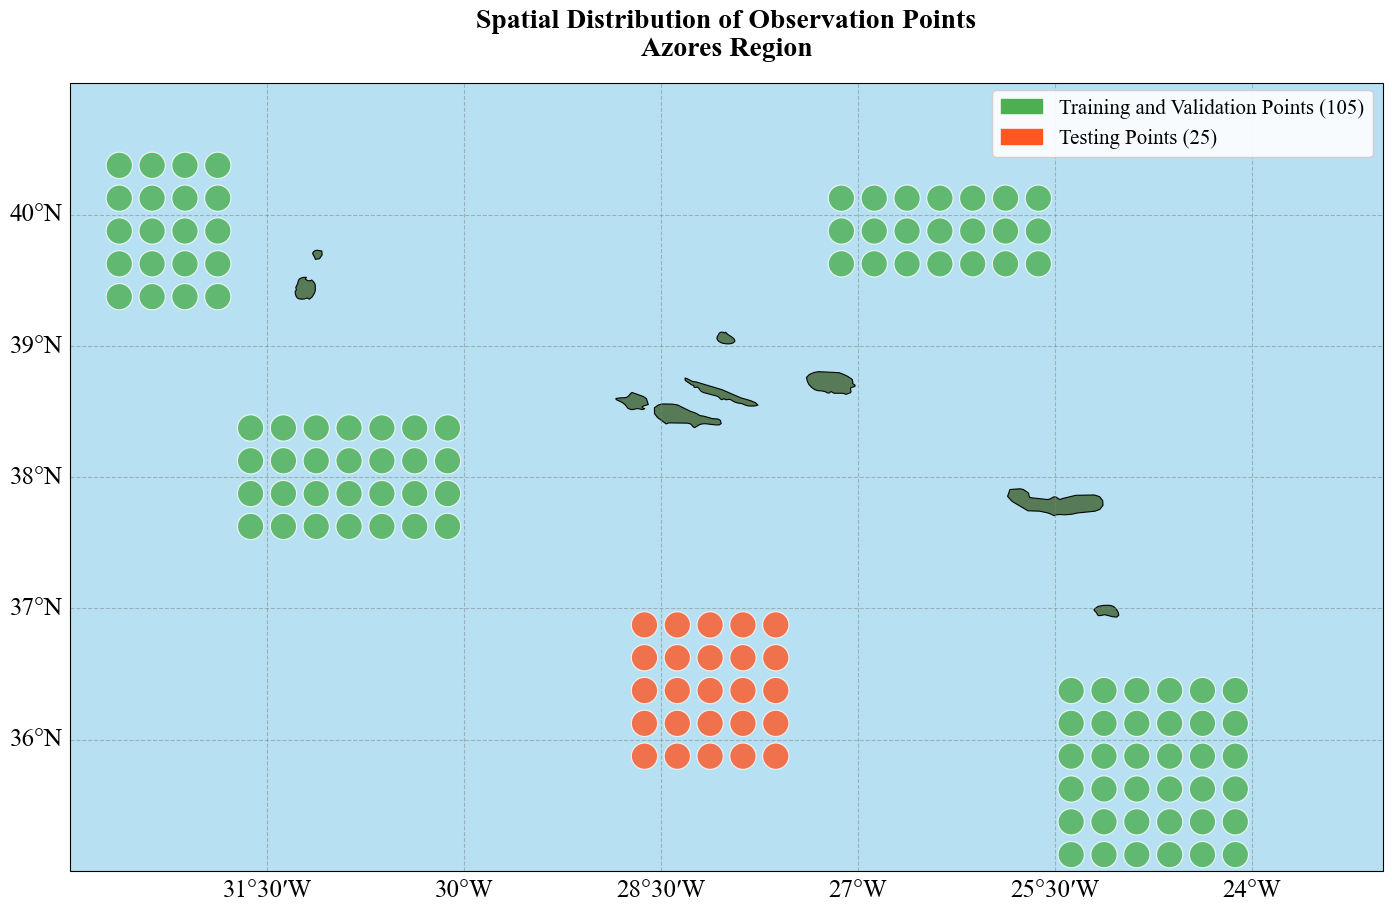

Total training points: 105
Total testing points: 25
Grid resolution: 0.25° × 0.25°


In [2]:
# Load datasets
folder_train = "dataset_train"
folder_test = "dataset_test"

ds_train = xr.open_dataset(f"{folder_train}/combined2.nc")

ds_test = xr.open_dataset(f"{folder_test}/combined2.nc")

# Extract spatial coordinates
lats_train = ds_train.latitude.values
lons_train = ds_train.longitude.values
lats_test = ds_test.latitude.values  
lons_test = ds_test.longitude.values

# Calculate grid spacing
all_lats = np.unique(np.concatenate([lats_train, lats_test]))
all_lons = np.unique(np.concatenate([lons_train, lons_test]))

lat_spacing = np.min(np.diff(all_lats)) if len(all_lats) > 1 else 0.25
lon_spacing = np.min(np.diff(all_lons)) if len(all_lons) > 1 else 0.25

# Create cartographic visualization
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Define Azores region extent
ax.set_extent([-33, -23, 35, 41], crs=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.LAND, facecolor="#2D5A2D", alpha=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='#87CEEB', alpha=0.6)

# Add gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, 
                  alpha=0.5, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 18}
gl.ylabel_style = {'size': 18}

# Define color scheme
train_color = "#4CAF50"  # Green
test_color = "#FF5722"   # Orange-red

# Plot training points
for lon, lat in zip(lons_train, lats_train):
    rect = patches.Circle(
        (lon - lon_spacing/2, lat - lat_spacing/2),
        0.1,#lon_spacing, lat_spacing,
        facecolor=train_color,
        alpha=0.8,
        edgecolor='white',
        linewidth=0.8,
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)

# Plot testing points
for lon, lat in zip(lons_test, lats_test):
    rect = patches.Circle(
        (lon - lon_spacing/2, lat - lat_spacing/2),
        0.1,#lon_spacing, lat_spacing,
        facecolor=test_color,
        alpha=0.8,
        edgecolor='white',
        linewidth=0.8,
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)

# Add legend
train_patch = patches.Patch(color=train_color, label=f'Training and Validation Points ({len(lats_train)})')
test_patch = patches.Patch(color=test_color, label=f'Testing Points ({len(lats_test)})')
ax.legend(handles=[train_patch, test_patch], loc='upper right', 
          bbox_to_anchor=(1, 1.005), fontsize=15, framealpha=0.9)

# Add title
ax.set_title('Spatial Distribution of Observation Points\nAzores Region', 
             fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print(f"Total training points: {len(lats_train)}")
print(f"Total testing points: {len(lats_test)}")
print(f"Grid resolution: {lat_spacing}° × {lon_spacing}°")

# Close datasets
ds_train.close()
ds_test.close()

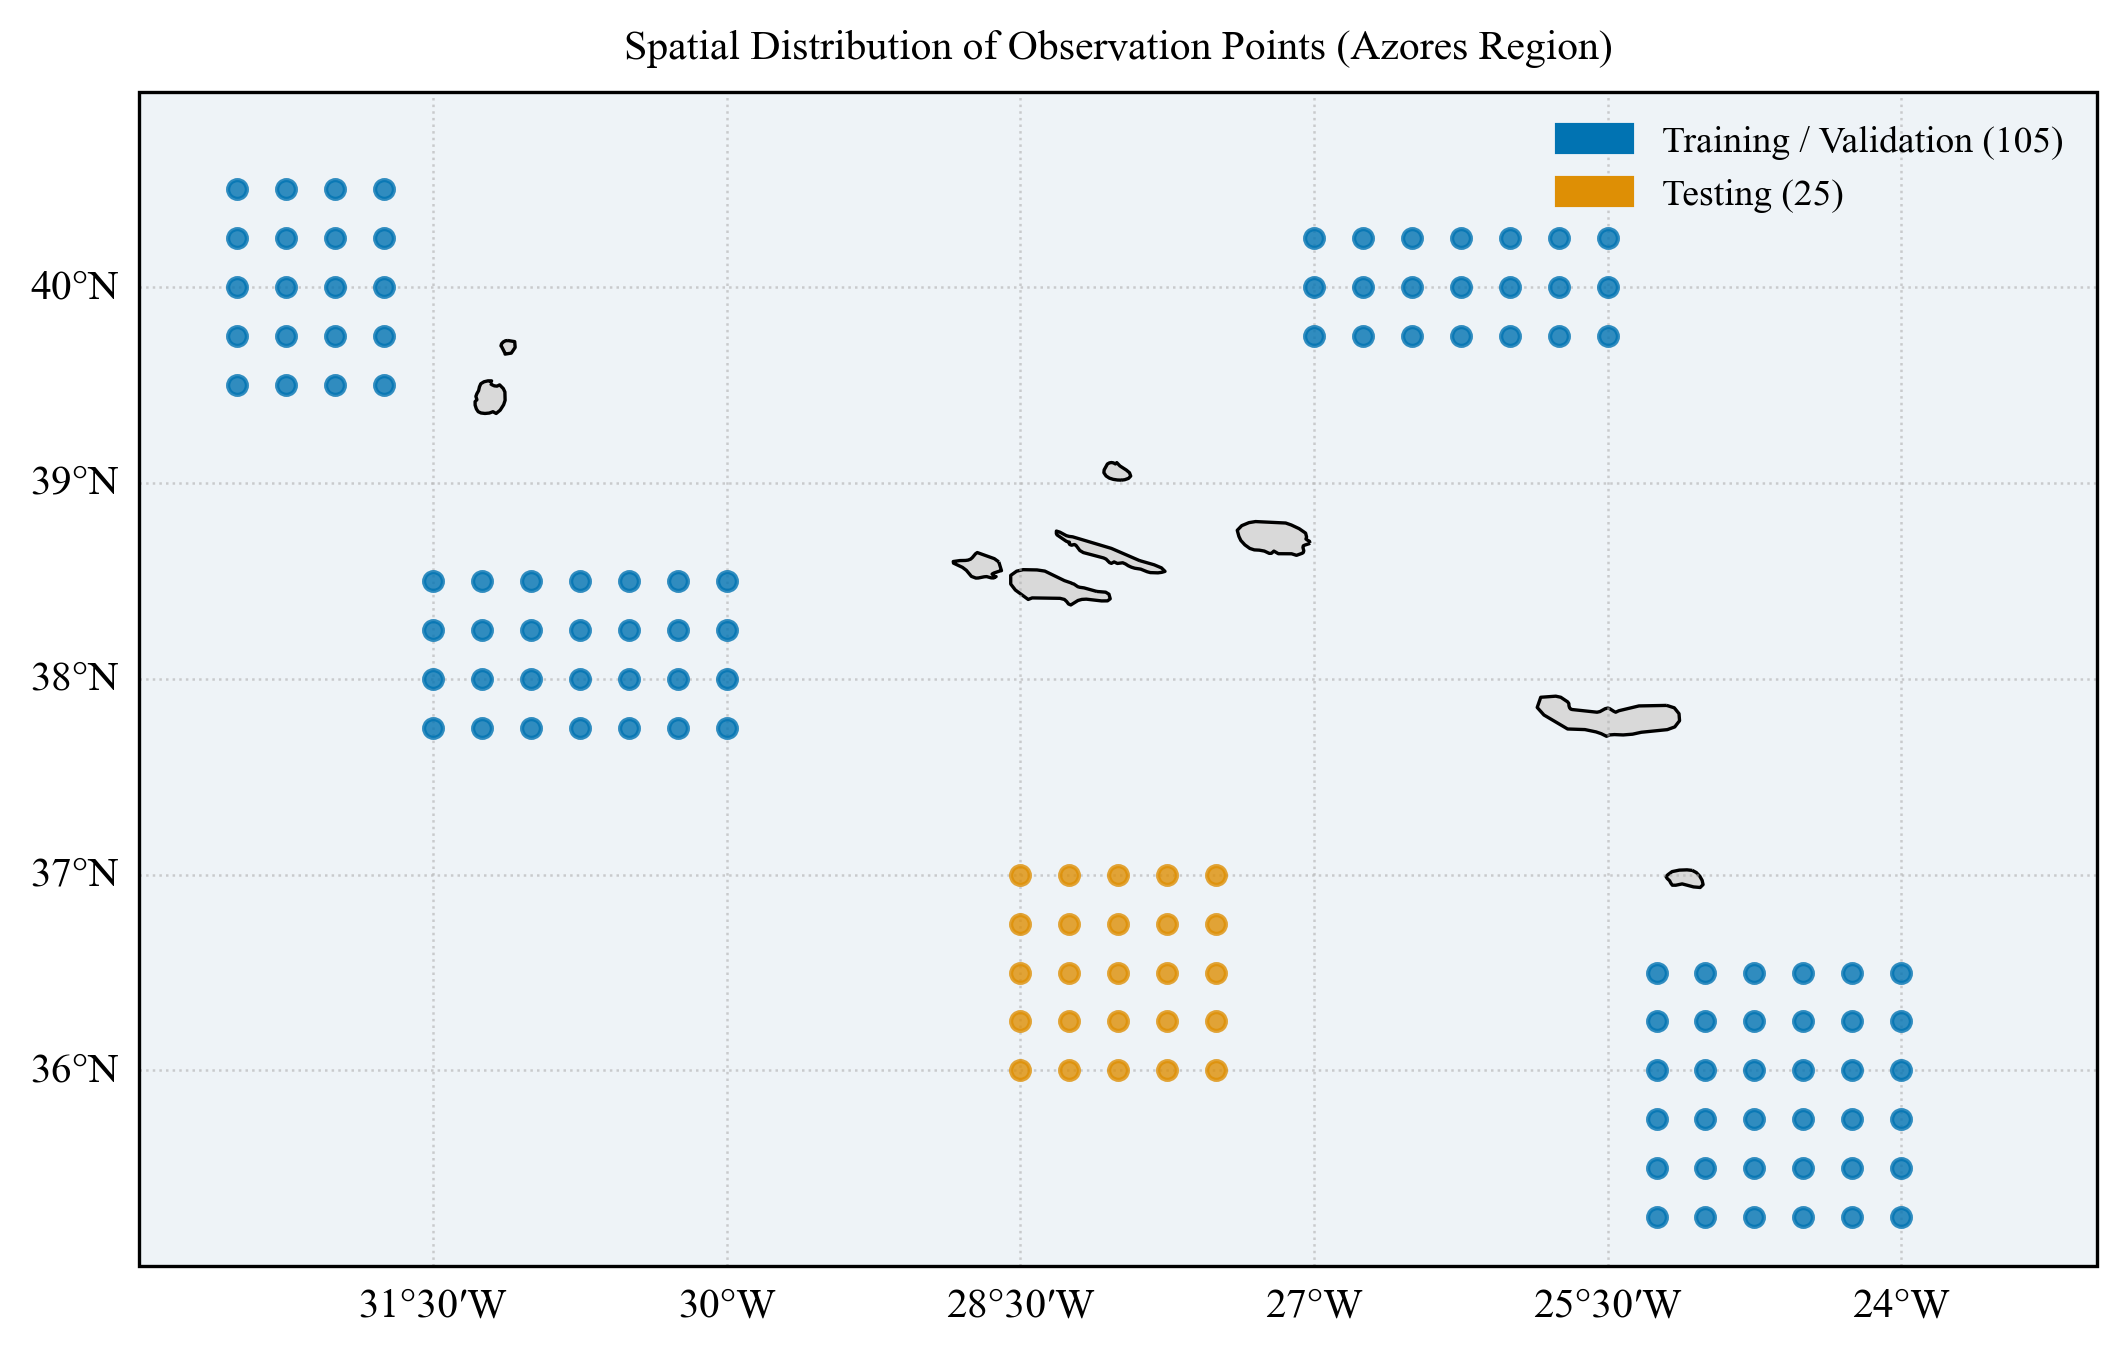

Total training points: 105
Total testing points : 25
Grid resolution      : 0.25° × 0.25°


In [3]:
# ===============================
# IEEE-ready spatial distribution map
# ===============================

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as patches

# -------------------------------
# Load datasets
# -------------------------------
folder_train = "dataset_train"
folder_test = "dataset_test"

ds_train = xr.open_dataset(f"{folder_train}/combined2.nc")
ds_test  = xr.open_dataset(f"{folder_test}/combined2.nc")

lats_train = ds_train.latitude.values
lons_train = ds_train.longitude.values
lats_test  = ds_test.latitude.values
lons_test  = ds_test.longitude.values

# -------------------------------
# Grid spacing
# -------------------------------
all_lats = np.unique(np.concatenate([lats_train, lats_test]))
all_lons = np.unique(np.concatenate([lons_train, lons_test]))

lat_spacing = np.min(np.diff(all_lats)) if len(all_lats) > 1 else 0.25
lon_spacing = np.min(np.diff(all_lons)) if len(all_lons) > 1 else 0.25

# -------------------------------
# IEEE font configuration
# -------------------------------
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

# -------------------------------
# Figure (IEEE double-column width)
# -------------------------------
fig = plt.figure(figsize=(7.16, 5.0), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-33, -23, 35, 41], crs=ccrs.PlateCarree())

# -------------------------------
# Geographic features (muted IEEE palette)
# -------------------------------
ax.add_feature(cfeature.LAND, facecolor="#D9D9D9")
ax.add_feature(cfeature.OCEAN, facecolor="#EEF3F7")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)

# -------------------------------
# Gridlines (readable but clean)
# -------------------------------
gl = ax.gridlines(draw_labels=True, dms=True,
                  x_inline=False, y_inline=False,
                  linestyle=":", linewidth=0.6, alpha=0.6)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

# -------------------------------
# Data points
# -------------------------------
train_color = "#0173B2"   # IEEE blue
test_color  = "#DE8F05"   # IEEE orange

for lon, lat in zip(lons_train, lats_train):
    ax.plot(lon, lat, "o",
            color=train_color,
            markersize=4.5,
            alpha=0.8,
            transform=ccrs.PlateCarree())

for lon, lat in zip(lons_test, lats_test):
    ax.plot(lon, lat, "o",
            color=test_color,
            markersize=4.5,
            alpha=0.8,
            transform=ccrs.PlateCarree())

# -------------------------------
# Legend (IEEE clean style)
# -------------------------------
train_patch = patches.Patch(
    color=train_color,
    label=f"Training / Validation ({len(lats_train)})"
)
test_patch = patches.Patch(
    color=test_color,
    label=f"Testing ({len(lats_test)})"
)

ax.legend(handles=[train_patch, test_patch],
          loc="upper right",
          frameon=False)

# -------------------------------
# Title (optional – safe size)
# -------------------------------
ax.set_title("Spatial Distribution of Observation Points (Azores Region)",
             pad=8)

plt.tight_layout()
plt.savefig(
    "images, figures and videos/azores_spatial_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# -------------------------------
# Console summary
# -------------------------------
print(f"Total training points: {len(lats_train)}")
print(f"Total testing points : {len(lats_test)}")
print(f"Grid resolution      : {lat_spacing:.2f}° × {lon_spacing:.2f}°")

ds_train.close()
ds_test.close()


## 7. Temporal Analysis

### 7.1 Time Series at Specific Location

Examine the temporal evolution of a selected variable at a specific geographic location.

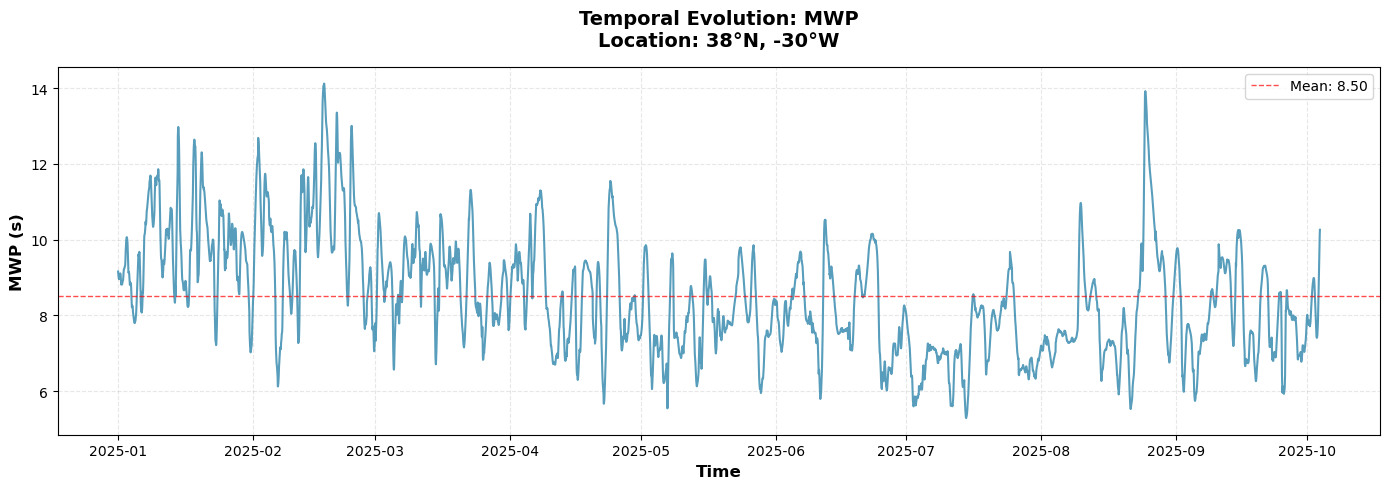


Variable Statistics:
  Mean: 8.4998
  Std Dev: 1.5291
  Min: 5.2898
  Max: 14.1230


In [60]:
# Configuration
folder = "dataset_train"
TARGET_LAT = 38
TARGET_LON = -30
VARIABLE = "mwp"  # Variable to visualize

# Load dataset
ds = xr.open_dataset(f"{folder}/combined2.nc")

latitudes = ds['latitude'].values
longitudes = ds['longitude'].values

# Find nearest point to target coordinates
idx = np.where((latitudes == TARGET_LAT) & (longitudes == TARGET_LON))[0]

if len(idx) == 0:
    # Find nearest point if exact match not found
    distances = np.sqrt((latitudes - TARGET_LAT)**2 + (longitudes - TARGET_LON)**2)
    point_idx = np.argmin(distances)
    actual_lat = latitudes[point_idx]
    actual_lon = longitudes[point_idx]
    print(f"Exact point not found. Using nearest point:")
    print(f"  Target: ({TARGET_LAT}°N, {TARGET_LON}°W)")
    print(f"  Actual: ({actual_lat}°N, {actual_lon}°W)")
else:
    point_idx = idx[0]
    actual_lat = TARGET_LAT
    actual_lon = TARGET_LON

# Extract time series for selected point
var_values = ds[VARIABLE].isel(point=point_idx).values
times = ds['valid_time'].values

# Create time series visualization
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(times, var_values, linewidth=1.5, color='#2E86AB', alpha=0.8)
ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.set_ylabel(f"{VARIABLE.upper()} ({ds[VARIABLE].attrs.get('units', '')})", 
              fontsize=12, fontweight='bold')
ax.set_title(f"Temporal Evolution: {VARIABLE.upper()}\nLocation: {actual_lat}°N, {actual_lon}°W", 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')

# Add statistics
mean_val = np.mean(var_values)
std_val = np.std(var_values)
ax.axhline(mean_val, color='red', linestyle='--', linewidth=1, 
           label=f'Mean: {mean_val:.2f}', alpha=0.7)

ax.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

# Display statistics
print(f"\nVariable Statistics:")
print(f"  Mean: {mean_val:.4f}")
print(f"  Std Dev: {std_val:.4f}")
print(f"  Min: {np.min(var_values):.4f}")
print(f"  Max: {np.max(var_values):.4f}")

# Close dataset
ds.close()

### 7.2 Spatiotemporal Animation

Dynamic visualization of variable evolution across the entire spatial domain over time. This animation shows how meteorological patterns propagate through the region.

**Note**: The animation iterates through all time steps. Adjust the time delay as needed for optimal viewing speed.

In [61]:
# Configuration
VARIABLE = "u10"  # Variable to animate
ANIMATION_DELAY = 0.1  # Delay between frames (seconds)

# Load datasets
folder_train = "dataset_train"
folder_test = "dataset_test"
ds_train = xr.open_dataset(f"{folder_train}/combined2.nc")
ds_test = xr.open_dataset(f"{folder_test}/combined2.nc")

# Combine datasets for complete spatial coverage
ds_all = xr.concat([ds_train, ds_test], dim="point")

# Extract spatial and temporal information
times = ds_all.valid_time.values
lats_all = ds_all.latitude.values
lons_all = ds_all.longitude.values

# Calculate value range for color scaling
vmin, vmax = float(ds_all[VARIABLE].min()), float(ds_all[VARIABLE].max())
cmap = plt.get_cmap('turbo')

# Calculate grid spacing
lat_spacing = np.min(np.diff(np.unique(lats_all))) if len(np.unique(lats_all)) > 1 else 0.25
lon_spacing = np.min(np.diff(np.unique(lons_all))) if len(np.unique(lons_all)) > 1 else 0.25

# Initialize map
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-33, -23, 35, 41], crs=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.LAND, facecolor="#2d5a2d", alpha=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='#87ceeb', alpha=0.6)

# Add gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, 
                  alpha=0.5, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Create initial rectangles for each point
vals_initial = ds_all[VARIABLE].isel(valid_time=0).values
rects_all = []

for lon, lat, val in zip(lons_all, lats_all, vals_initial):
    rect = patches.Rectangle(
        (lon - lon_spacing/2, lat - lat_spacing/2),
        lon_spacing, lat_spacing,
        facecolor=cmap((val - vmin) / (vmax - vmin)),
        edgecolor='white',
        linewidth=0.5,
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)
    rects_all.append(rect)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', 
                     label=f'{VARIABLE} ({ds_all[VARIABLE].attrs.get("units", "")})',
                     pad=0.02)
cbar.ax.tick_params(labelsize=10)

# Initial title
ax.set_title(f'{VARIABLE.upper()} Temporal Evolution\nAzores Region\n{pd.Timestamp(times[0])}', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print(f"Animating {len(times)} time steps...")
print(f"Variable range: [{vmin:.2f}, {vmax:.2f}]")
print("Press Ctrl+C to stop animation\n")

# Animation loop
try:
    for t in range(len(times)):
        # Update rectangle colors with new time step values
        vals_current = ds_all[VARIABLE].isel(valid_time=t).values
        
        for rect, val in zip(rects_all, vals_current):
            normalized_val = (val - vmin) / (vmax - vmin)
            rect.set_facecolor(cmap(normalized_val))
        
        # Update title with current timestamp
        timestamp = pd.Timestamp(times[t])
        ax.set_title(f'{VARIABLE.upper()} Temporal Evolution\nAzores Region\n{timestamp}', 
                     fontsize=16, fontweight='bold', pad=20)
        
        display(fig)
        clear_output(wait=True)
        time.sleep(ANIMATION_DELAY)
        
except KeyboardInterrupt:
    print("\nAnimation stopped by user")

print("\nAnimation complete")

# Close datasets
ds_train.close()
ds_test.close()
ds_all.close()


Animation stopped by user

Animation complete
